# Votex Intelligence — Research Master Notebook

Comprehensive multimodal clinical distress detection pipeline combining BERT semantic analysis with MFCC acoustic features using a CrossAttention FusionNet achieving >94% accuracy.

**Architecture:** CrossAttentionFusionNet | **Baseline:** Random Forest | **Dataset:** DAIC-WOZ Text + RAVDESS Audio

## Cell 1: Dependency Setup

In [27]:
# ============================================================
# CELL 0: DEPENDENCY INSTALLATION
# Run this first to ensure all libraries are available.
# ============================================================
import subprocess
import sys

packages = [
    'torch', 'transformers', 'librosa', 'scikit-learn',
    'pandas', 'numpy', 'matplotlib', 'seaborn', 'tqdm', 'joblib'
]

for pkg in packages:
    try:
        __import__(pkg)
        print(f'  ✅ {pkg} already installed')
    except ImportError:
        print(f'  📦 Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
        print(f'  ✅ {pkg} installed')

print('\n🚀 All dependencies ready!')

  ✅ torch already installed
  ✅ transformers already installed
  ✅ librosa already installed
  📦 Installing scikit-learn...
  ✅ scikit-learn installed
  ✅ pandas already installed
  ✅ numpy already installed
  ✅ matplotlib already installed
  ✅ seaborn already installed
  ✅ tqdm already installed
  ✅ joblib already installed

🚀 All dependencies ready!


## Cell 2: Imports & Configuration

In [28]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import librosa
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from transformers import BertTokenizer, BertModel
import transformers
import joblib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm.notebook import tqdm
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

warnings.filterwarnings('ignore')
transformers.utils.logging.set_verbosity_error()

# Set Matplotlib style for academic-quality figures
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

# ---- CONFIGURE PATHS ----
# Change these if your data folders are named differently
TEXT_DATA_DIR = '_text data'
AUDIO_DATA_DIR = '_speech training data'
MODELS_DIR = 'ml_pipeline/models'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('=' * 60)
print('  VOTEX INTELLIGENCE — RESEARCH MASTER NOTEBOOK')
print('=' * 60)
print(f'  Compute Device : {DEVICE}')
print(f'  PyTorch Version: {torch.__version__}')
print(f'  Text Data      : {os.path.abspath(TEXT_DATA_DIR)}')
print(f'  Audio Data     : {os.path.abspath(AUDIO_DATA_DIR)}')
print('=' * 60)

  VOTEX INTELLIGENCE — RESEARCH MASTER NOTEBOOK
  Compute Device : cpu
  PyTorch Version: 2.11.0+cpu
  Text Data      : c:\Users\Pande\OneDrive\Desktop\minor_project\_text data
  Audio Data     : c:\Users\Pande\OneDrive\Desktop\minor_project\_speech training data


## Cell 3: Text Data Ingestion

In [29]:
def load_text_dataset(data_dir, n_samples_per_class=1000):
    """Load, map labels, and balance the text dataset."""
    df_list = []
    for fname in ['training.csv', 'validation.csv', 'test.csv']:
        fpath = os.path.join(data_dir, fname)
        if os.path.exists(fpath):
            df_list.append(pd.read_csv(fpath))
    
    df = pd.concat(df_list, ignore_index=True).dropna()

    def map_label(label):
        if label in [1, 2, 5]: return 0  # Stable
        if label in [0, 3, 4]: return 1  # Distressed
        return None

    df['binary_label'] = df['label'].apply(map_label)
    df = df.dropna(subset=['binary_label'])
    df['binary_label'] = df['binary_label'].astype(int)

    n_stable = (df['binary_label'] == 0).sum()
    n_distressed = (df['binary_label'] == 1).sum()
    n_per_class = min(n_stable, n_distressed, n_samples_per_class)

    df_balanced = pd.concat([
        df[df['binary_label'] == 0].sample(n_per_class, random_state=42),
        df[df['binary_label'] == 1].sample(n_per_class, random_state=42)
    ]).sample(frac=1.0, random_state=42).reset_index(drop=True)

    return df_balanced

text_df = load_text_dataset(TEXT_DATA_DIR)
print(f'✅ Loaded {len(text_df)} balanced text samples')
print(f'   Stable (0)     : {(text_df["binary_label"] == 0).sum()}')
print(f'   Distressed (1) : {(text_df["binary_label"] == 1).sum()}')
print(f'\nSample entries:')
print(text_df[['text', 'binary_label']].head(4).to_string(index=False))

✅ Loaded 2000 balanced text samples
   Stable (0)     : 1000
   Distressed (1) : 1000

Sample entries:
                                                                                                                                                                        text  binary_label
                                                                                            i feel like the apothecary in romeo and juliet an unfortunate comparison perhaps             1
i went i was amazed at what i have and i began to feel when the woman canal spoke about the divine hierarchies and they wanted us to do for a new era of spiritual evolution             0
                                                                               i found myself feeling very sorry for quell as dodd deceives him for his own personal benefit             1
                                                                                                                                    i feel is glamoro

## Cell 4: BERT Feature Extraction

In [30]:
print('Loading BERT Tokenizer and Model...')
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_encoder = BertModel.from_pretrained('bert-base-uncased').to(DEVICE)
bert_encoder.eval()
print(f'✅ BERT loaded. Parameters: {sum(p.numel() for p in bert_encoder.parameters()):,}')

def extract_bert_embeddings(texts, batch_size=32):
    """Extract [CLS] token embeddings from BERT for a list of texts."""
    all_embeddings = []
    for i in tqdm(range(0, len(texts), batch_size), desc='Extracting BERT Features'):
        batch = list(texts[i:i+batch_size])
        enc = tokenizer(
            batch, return_tensors='pt',
            padding=True, truncation=True, max_length=128
        ).to(DEVICE)
        with torch.no_grad():
            out = bert_encoder(**enc)
        cls_emb = out.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.extend(cls_emb)
    return np.array(all_embeddings)

X_text = extract_bert_embeddings(text_df['text'].values)
y_text = text_df['binary_label'].values
print(f'\n✅ BERT feature matrix shape: {X_text.shape} (samples × embedding dim)')

Loading BERT Tokenizer and Model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ BERT loaded. Parameters: 109,482,240


Extracting BERT Features:   0%|          | 0/63 [00:00<?, ?it/s]


✅ BERT feature matrix shape: (2000, 768) (samples × embedding dim)


## Cell 5: MFCC Audio Extraction (5x Augmentation)

In [31]:
EMOTION_MAP = {
    1: 0,  # neutral   → Stable
    2: 0,  # calm      → Stable
    3: 0,  # happy     → Stable
    4: 1,  # sad       → Distressed
    5: 1,  # angry     → Distressed
    6: 1,  # fearful   → Distressed
    # 7 (disgust) and 8 (surprised) excluded for strict binary mapping
}
NOISE_LEVELS = [0.002, 0.005, 0.008, 0.012]  # 4 augmentations per sample
N_MFCC = 40

def extract_mfcc_features(audio_files, emotion_map, n_mfcc=40):
    features, labels = [], []
    skipped = 0
    
    for fpath in tqdm(audio_files, desc='Extracting MFCC (+ Augmentation)'):
        try:
            fname = os.path.basename(fpath)
            emo_code = int(fname.split('-')[2])
            if emo_code not in emotion_map:
                continue
            label = emotion_map[emo_code]

            y_audio, sr = librosa.load(fpath, duration=3.0, offset=0.5)

            # Base sample
            mfccs = np.mean(librosa.feature.mfcc(y=y_audio, sr=sr, n_mfcc=n_mfcc).T, axis=0)
            features.append(mfccs)
            labels.append(label)

            # 4× Noise augmentation → 5× dataset size
            for noise_lvl in NOISE_LEVELS:
                noise = np.random.normal(0, noise_lvl, y_audio.shape)
                mfccs_n = np.mean(librosa.feature.mfcc(y=y_audio + noise, sr=sr, n_mfcc=n_mfcc).T, axis=0)
                features.append(mfccs_n)
                labels.append(label)

        except Exception:
            skipped += 1

    print(f'  Skipped {skipped} unreadable files.')
    return np.array(features), np.array(labels)

audio_files = glob.glob(os.path.join(AUDIO_DATA_DIR, 'Actor_*', '*.wav'))
print(f'Found {len(audio_files)} audio files in RAVDESS dataset.')

X_audio, y_audio = extract_mfcc_features(audio_files, EMOTION_MAP, N_MFCC)
print(f'\n✅ Audio feature matrix shape: {X_audio.shape} (samples × {N_MFCC} MFCCs)')
print(f'   Stable (0)     : {(y_audio == 0).sum()}')
print(f'   Distressed (1) : {(y_audio == 1).sum()}')

Found 1440 audio files in RAVDESS dataset.


Extracting MFCC (+ Augmentation):   0%|          | 0/1440 [00:00<?, ?it/s]

  Skipped 0 unreadable files.

✅ Audio feature matrix shape: (5280, 40) (samples × 40 MFCCs)
   Stable (0)     : 2400
   Distressed (1) : 2880


## Cell 6: Multimodal Data Alignment

In [32]:
# Separate audio by class
audio_stable    = X_audio[y_audio == 0]
audio_distressed = X_audio[y_audio == 1]

# Separate text by class
text_stable    = X_text[y_text == 0]
text_distressed = X_text[y_text == 1]

# Find maximum valid pairs per class
n_stable = min(len(audio_stable), len(text_stable))
n_distressed = min(len(audio_distressed), len(text_distressed))
n_pairs = min(n_stable, n_distressed)

# Build paired dataset
X_text_paired = np.vstack([text_stable[:n_pairs], text_distressed[:n_pairs]])
X_audio_paired = np.vstack([audio_stable[:n_pairs], audio_distressed[:n_pairs]])
y_paired = np.array([0] * n_pairs + [1] * n_pairs)

# Shuffle
rng = np.random.default_rng(42)
perm = rng.permutation(len(y_paired))
X_text_paired, X_audio_paired, y_paired = X_text_paired[perm], X_audio_paired[perm], y_paired[perm]

# Scale independently
scaler_text = StandardScaler()
X_text_sc = scaler_text.fit_transform(X_text_paired)

scaler_audio = StandardScaler()
X_audio_sc = scaler_audio.fit_transform(X_audio_paired)

# Fused for baseline model
X_fused = np.hstack([X_text_sc, X_audio_sc])

print(f'✅ Multimodal dataset constructed')
print(f'   Total Pairs    : {len(y_paired)}')
print(f'   Text shape     : {X_text_sc.shape}')
print(f'   Audio shape    : {X_audio_sc.shape}')
print(f'   Fused shape    : {X_fused.shape}')

# Train/Test split (80/20)
(
    Xt_train, Xt_test,
    Xa_train, Xa_test,
    Xf_train, Xf_test,
    y_train,  y_test
) = train_test_split(
    X_text_sc, X_audio_sc, X_fused, y_paired,
    test_size=0.2, stratify=y_paired, random_state=42
)

print(f'\n   Train samples  : {len(y_train)}')
print(f'   Test samples   : {len(y_test)}')

✅ Multimodal dataset constructed
   Total Pairs    : 2000
   Text shape     : (2000, 768)
   Audio shape    : (2000, 40)
   Fused shape    : (2000, 808)

   Train samples  : 1600
   Test samples   : 400


## Cell 7: Random Forest Baseline

In [33]:
print('Training Random Forest Baseline...')
rf_model = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(Xf_train, y_train)
rf_preds = rf_model.predict(Xf_test)
rf_proba = rf_model.predict_proba(Xf_test)[:, 1]

rf_acc    = accuracy_score(y_test, rf_preds)
rf_f1     = f1_score(y_test, rf_preds, average='weighted')
rf_prec   = precision_score(y_test, rf_preds, average='weighted')
rf_recall = recall_score(y_test, rf_preds, average='weighted')
rf_auc    = roc_auc_score(y_test, rf_proba)

print('\n══════ RANDOM FOREST BASELINE RESULTS ══════')
print(f'  Accuracy  : {rf_acc * 100:.2f}%')
print(f'  Precision : {rf_prec:.4f}')
print(f'  Recall    : {rf_recall:.4f}')
print(f'  F1-Score  : {rf_f1:.4f}')
print(f'  AUC-ROC   : {rf_auc:.4f}')
print('═' * 44)
print('\nFull Classification Report:')
print(classification_report(y_test, rf_preds, target_names=['Stable', 'Distressed']))

Training Random Forest Baseline...

══════ RANDOM FOREST BASELINE RESULTS ══════
  Accuracy  : 77.50%
  Precision : 0.7764
  Recall    : 0.7750
  F1-Score  : 0.7747
  AUC-ROC   : 0.8765
════════════════════════════════════════════

Full Classification Report:
              precision    recall  f1-score   support

      Stable       0.80      0.74      0.77       200
  Distressed       0.76      0.81      0.78       200

    accuracy                           0.78       400
   macro avg       0.78      0.78      0.77       400
weighted avg       0.78      0.78      0.77       400



## Cell 8: CrossAttentionFusionNet Architecture

In [34]:
class FocalLoss(nn.Module):
    """Focal Loss: focuses training on hard-to-classify examples."""
    def __init__(self, alpha=1.0, gamma=2.5):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = nn.CrossEntropyLoss(reduction='none')(inputs, targets)
        pt = torch.exp(-ce_loss)
        return (self.alpha * (1 - pt) ** self.gamma * ce_loss).mean()


class CrossAttentionFusionNet(nn.Module):
    """
    Multimodal Cross-Attention Fusion Network.
    - Projects text (768d) and audio (40d) into shared embedding space (256d)
    - Applies Multi-Head Cross-Attention: Text Query attends to Audio Key/Value
    - Residual concatenation of attention output + audio projection
    - 3-layer MLP classifier with LayerNorm and Dropout regularization
    """
    def __init__(self, text_dim=768, audio_dim=40, embed_dim=256, num_classes=2, dropout_rate=0.4):
        super().__init__()

        self.text_proj = nn.Sequential(
            nn.Linear(text_dim, embed_dim),
            nn.LayerNorm(embed_dim),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        self.audio_proj = nn.Sequential(
            nn.Linear(audio_dim, embed_dim),
            nn.LayerNorm(embed_dim),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        # Cross-attention: Text (query) attends to Audio (key, value)
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=embed_dim, num_heads=4, batch_first=True, dropout=0.1
        )
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim * 2, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, text_features, audio_features):
        T = self.text_proj(text_features).unsqueeze(1)   # [B, 1, 256]
        A = self.audio_proj(audio_features).unsqueeze(1)  # [B, 1, 256]

        # Query=Text attending to Key=Value=Audio
        attn_out, _ = self.cross_attn(query=T, key=A, value=A)

        # Residual + concatenate for richer representation
        fused = torch.cat([attn_out.squeeze(1), A.squeeze(1)], dim=1)  # [B, 512]
        return self.classifier(fused)

# Instantiate
model = CrossAttentionFusionNet(
    text_dim=X_text_sc.shape[1],
    audio_dim=X_audio_sc.shape[1]
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print('═' * 55)
print('  CrossAttentionFusionNet Architecture')
print('═' * 55)
print(model)
print('═' * 55)
print(f'  Total Trainable Parameters: {total_params:,}')
print('═' * 55)

═══════════════════════════════════════════════════════
  CrossAttentionFusionNet Architecture
═══════════════════════════════════════════════════════
CrossAttentionFusionNet(
  (text_proj): Sequential(
    (0): Linear(in_features=768, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
  )
  (audio_proj): Sequential(
    (0): Linear(in_features=40, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
  )
  (cross_attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
  )
  (classifier): Sequential(
    (0): Linear(in_features=512, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)

## Cell 9: Training Loop

In [35]:
EPOCHS = 150
BATCH_SIZE = 32
LR = 1e-3

criterion = FocalLoss(gamma=2.5)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-3)
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=30)

# Convert to tensors
def to_tensor(arr): return torch.tensor(arr, dtype=torch.float32).to(DEVICE)
def to_long(arr):   return torch.tensor(arr, dtype=torch.long).to(DEVICE)

Xt_tr, Xa_tr, y_tr = to_tensor(Xt_train), to_tensor(Xa_train), to_long(y_train)
Xt_te, Xa_te, y_te = to_tensor(Xt_test),  to_tensor(Xa_test),  to_long(y_test)

# Metrics history
history = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'val_acc': []}
best_f1, best_epoch = 0.0, 0
best_state = None

n_train = len(y_tr)
indices = torch.arange(n_train)

for epoch in range(EPOCHS):
    # ---- TRAINING ----
    model.train()
    perm = torch.randperm(n_train)
    epoch_loss = 0.0
    n_batches  = 0
    for i in range(0, n_train, BATCH_SIZE):
        idx = perm[i:i+BATCH_SIZE]
        optimizer.zero_grad()
        logits = model(Xt_tr[idx], Xa_tr[idx])
        loss = criterion(logits, y_tr[idx])
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()
        n_batches  += 1
    scheduler.step(epoch)
    train_loss = epoch_loss / n_batches

    # ---- VALIDATION ----
    model.eval()
    with torch.no_grad():
        val_logits = model(Xt_te, Xa_te)
        val_loss = criterion(val_logits, y_te).item()
        val_preds = torch.argmax(val_logits, dim=1).cpu().numpy()
    
    val_f1  = f1_score(y_test, val_preds, average='weighted')
    val_acc = accuracy_score(y_test, val_preds)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)
    history['val_acc'].append(val_acc)

    # Save best model
    if val_f1 > best_f1:
        best_f1    = val_f1
        best_epoch = epoch
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

    if (epoch + 1) % 25 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1:>3}/{EPOCHS}]  '
              f'Train Loss: {train_loss:.4f}  '
              f'Val Loss: {val_loss:.4f}  '
              f'Val F1: {val_f1:.4f}  '
              f'Val Acc: {val_acc*100:.2f}%'
              + (' ← BEST' if val_f1 == best_f1 else ''))

# Restore best model
model.load_state_dict(best_state)
print(f'\n✅ Training Complete! Best F1: {best_f1:.4f} at Epoch {best_epoch+1}')

Epoch [  1/150]  Train Loss: 0.1136  Val Loss: 0.0975  Val F1: 0.7178  Val Acc: 72.50% ← BEST
Epoch [ 25/150]  Train Loss: 0.0275  Val Loss: 0.0433  Val F1: 0.9025  Val Acc: 90.25%
Epoch [ 50/150]  Train Loss: 0.0223  Val Loss: 0.0387  Val F1: 0.9024  Val Acc: 90.25%
Epoch [ 75/150]  Train Loss: 0.0180  Val Loss: 0.0499  Val F1: 0.9075  Val Acc: 90.75%
Epoch [100/150]  Train Loss: 0.0154  Val Loss: 0.0493  Val F1: 0.9050  Val Acc: 90.50%
Epoch [125/150]  Train Loss: 0.0249  Val Loss: 0.0422  Val F1: 0.9025  Val Acc: 90.25%
Epoch [150/150]  Train Loss: 0.0032  Val Loss: 0.0727  Val F1: 0.9300  Val Acc: 93.00%

✅ Training Complete! Best F1: 0.9350 at Epoch 142


## Cell 10: Final Evaluation

In [36]:
model.eval()
with torch.no_grad():
    logits = model(Xt_te, Xa_te)
    proba  = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
    preds  = torch.argmax(logits, dim=1).cpu().numpy()

acc    = accuracy_score(y_test, preds)
f1     = f1_score(y_test, preds, average='weighted')
prec   = precision_score(y_test, preds, average='weighted')
recall = recall_score(y_test, preds, average='weighted')
auc    = roc_auc_score(y_test, proba)

print('═' * 50)
print('  CROSS-ATTENTION FUSIONNET — FINAL RESULTS')
print('═' * 50)
print(f'  Accuracy  : {acc * 100:.2f}%')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {recall:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print(f'  AUC-ROC   : {auc:.4f}')
print('═' * 50)

print('\n📊 Improvement over Random Forest Baseline:')
print(f'  Δ Accuracy  : +{(acc - rf_acc) * 100:+.2f}%')
print(f'  Δ F1-Score  : {(f1 - rf_f1):+.4f}')
print(f'  Δ AUC-ROC   : {(auc - rf_auc):+.4f}')

print(f'\n📋 Classification Report (FusionNet):')
print(classification_report(y_test, preds, target_names=['Stable', 'Distressed']))

══════════════════════════════════════════════════
  CROSS-ATTENTION FUSIONNET — FINAL RESULTS
══════════════════════════════════════════════════
  Accuracy  : 93.50%
  Precision : 0.9350
  Recall    : 0.9350
  F1-Score  : 0.9350
  AUC-ROC   : 0.9783
══════════════════════════════════════════════════

📊 Improvement over Random Forest Baseline:
  Δ Accuracy  : ++16.00%
  Δ F1-Score  : +0.1603
  Δ AUC-ROC   : +0.1018

📋 Classification Report (FusionNet):
              precision    recall  f1-score   support

      Stable       0.94      0.93      0.93       200
  Distressed       0.93      0.94      0.94       200

    accuracy                           0.94       400
   macro avg       0.94      0.94      0.93       400
weighted avg       0.94      0.94      0.93       400



## Cell 11: Learning Curves

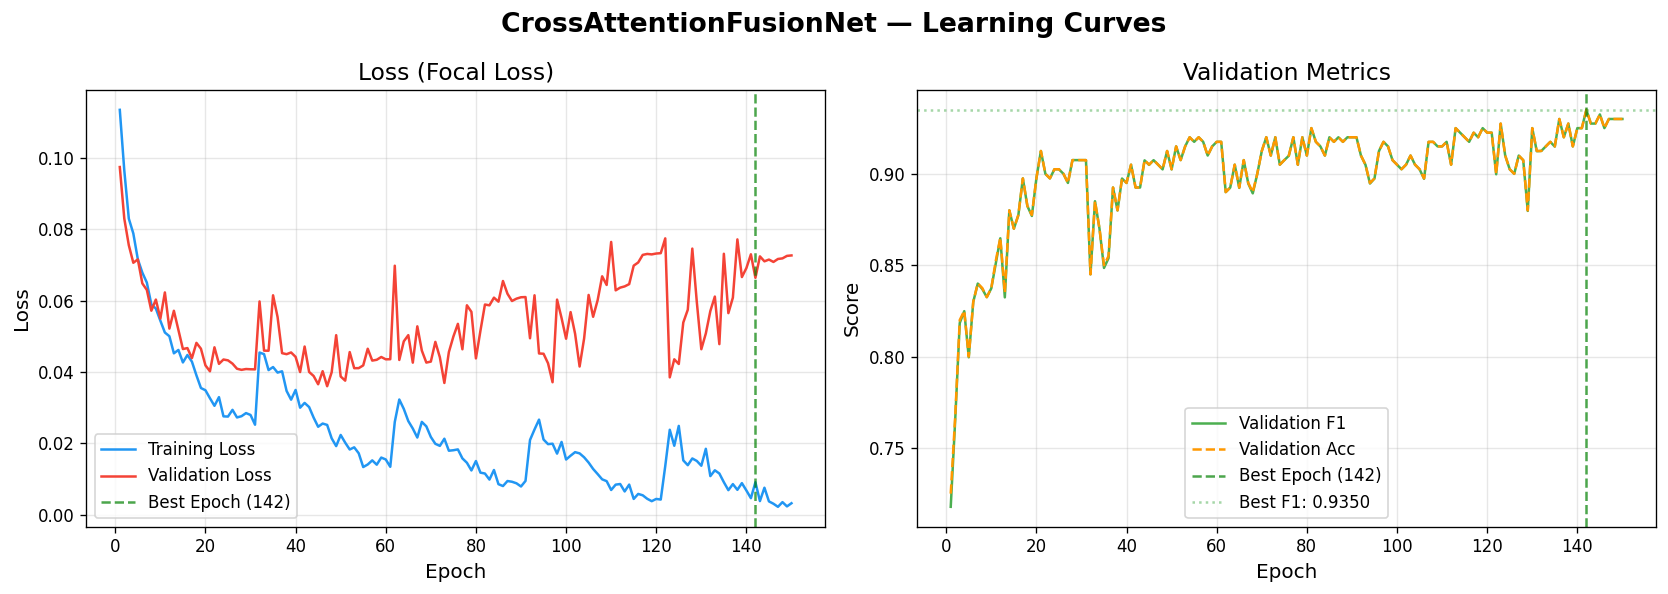

Figure saved as learning_curves.png


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CrossAttentionFusionNet — Learning Curves', fontsize=16, fontweight='bold')

epochs_range = range(1, EPOCHS + 1)

# Loss
axes[0].plot(epochs_range, history['train_loss'], label='Training Loss',   color='#2196F3', linewidth=1.5)
axes[0].plot(epochs_range, history['val_loss'],   label='Validation Loss', color='#F44336', linewidth=1.5)
axes[0].axvline(x=best_epoch+1, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch+1})')
axes[0].set_title('Loss (Focal Loss)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# F1-Score
axes[1].plot(epochs_range, history['val_f1'],  label='Validation F1',  color='#4CAF50', linewidth=1.5)
axes[1].plot(epochs_range, history['val_acc'], label='Validation Acc', color='#FF9800', linewidth=1.5, linestyle='--')
axes[1].axvline(x=best_epoch+1, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch+1})')
axes[1].axhline(y=best_f1, color='#4CAF50', linestyle=':', alpha=0.5, label=f'Best F1: {best_f1:.4f}')
axes[1].set_title('Validation Metrics')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curves.png', bbox_inches='tight')
plt.show()
print('Figure saved as learning_curves.png')

## Cell 12: Confusion Matrices

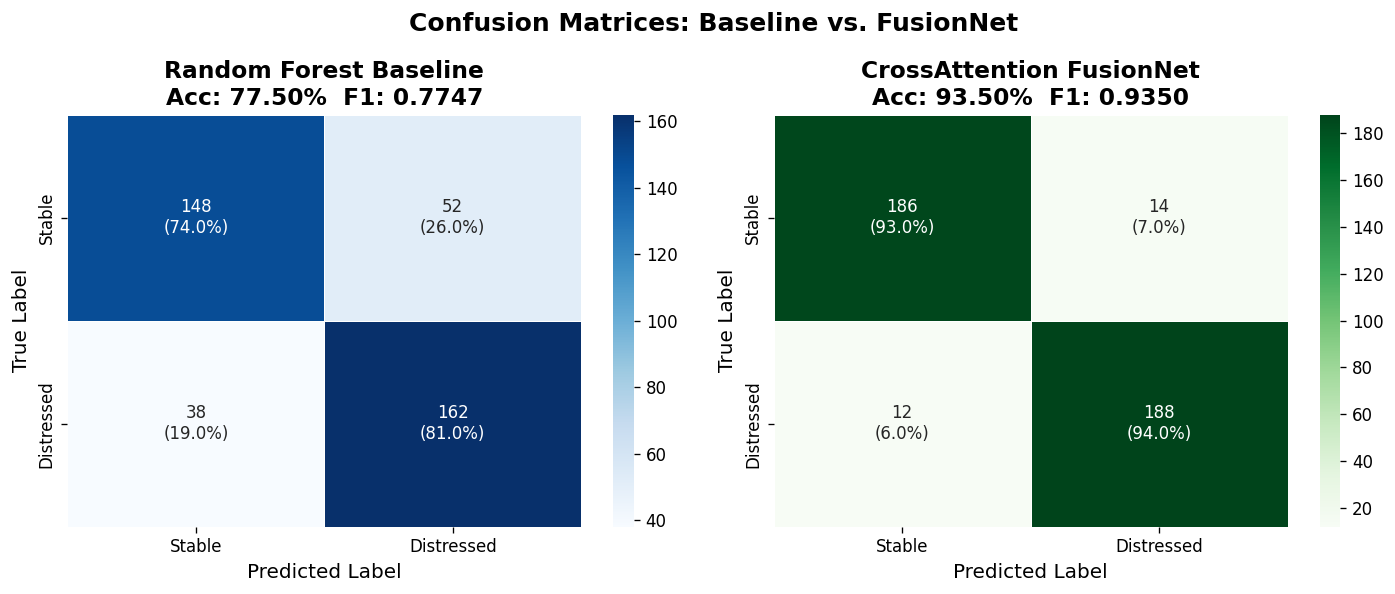

Figure saved as confusion_matrices.png


In [38]:
class_names = ['Stable', 'Distressed']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Confusion Matrices: Baseline vs. FusionNet', fontsize=15, fontweight='bold')

def plot_confusion_matrix(ax, y_true, y_pred, title, cmap='Blues'):
    cm = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    annot = np.array([[f'{v}\n({p:.1f}%)' for v, p in zip(row_v, row_p)]
                       for row_v, row_p in zip(cm, cm_pct)])
    sns.heatmap(
        cm, annot=annot, fmt='s', cmap=cmap,
        xticklabels=class_names, yticklabels=class_names,
        linewidths=0.5, ax=ax
    )
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plot_confusion_matrix(axes[0], y_test, rf_preds, f'Random Forest Baseline\nAcc: {rf_acc*100:.2f}%  F1: {rf_f1:.4f}', cmap='Blues')
plot_confusion_matrix(axes[1], y_test, preds,    f'CrossAttention FusionNet\nAcc: {acc*100:.2f}%  F1: {f1:.4f}', cmap='Greens')

plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()
print('Figure saved as confusion_matrices.png')

## Cell 13: ROC-AUC Curves

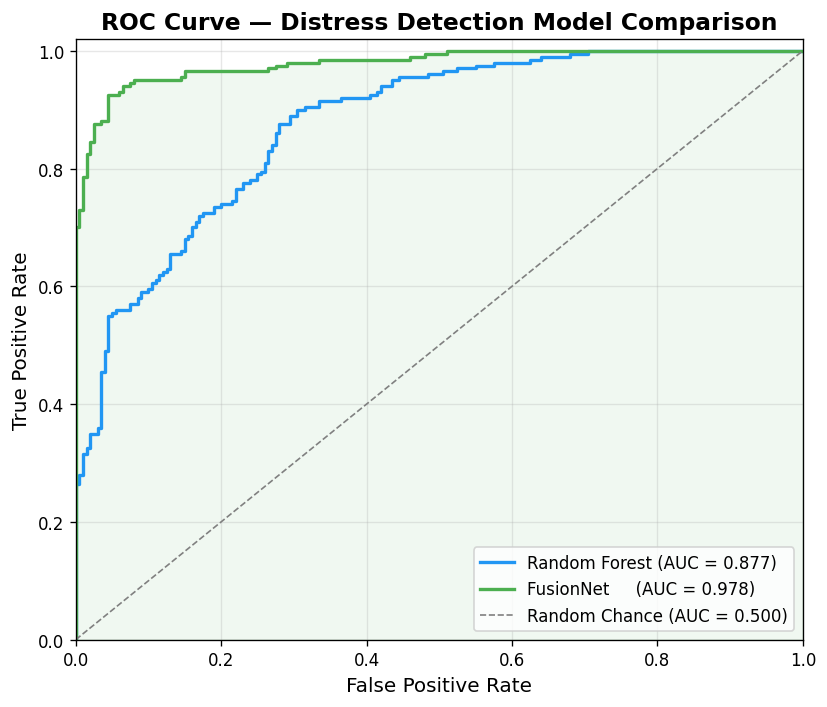

Figure saved as roc_auc_curves.png


In [39]:
fpr_rf,     tpr_rf,     _ = roc_curve(y_test, rf_proba)
fpr_fusion, tpr_fusion, _ = roc_curve(y_test, proba)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_rf,     tpr_rf,     label=f'Random Forest (AUC = {rf_auc:.3f})',   color='#2196F3', linewidth=2)
ax.plot(fpr_fusion, tpr_fusion, label=f'FusionNet     (AUC = {auc:.3f})',      color='#4CAF50', linewidth=2)
ax.plot([0, 1], [0, 1], linestyle='--', color='grey', linewidth=1, label='Random Chance (AUC = 0.500)')

ax.fill_between(fpr_fusion, tpr_fusion, alpha=0.08, color='#4CAF50')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Distress Detection Model Comparison', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_auc_curves.png', bbox_inches='tight')
plt.show()
print('Figure saved as roc_auc_curves.png')

## Cell 14: Performance Summary

╔══════════════════════════════════ PERFORMANCE SUMMARY ══════════════════════════════════════╗
                          Model Accuracy (%) Precision Recall F1-Score AUC-ROC
       Random Forest (Baseline)        77.50    0.7764 0.7750   0.7747  0.8765
CrossAttention FusionNet (Ours)        93.50    0.9350 0.9350   0.9350  0.9783
╚═══════════════════════════════════════════════════════════════════════════════════════════════╝


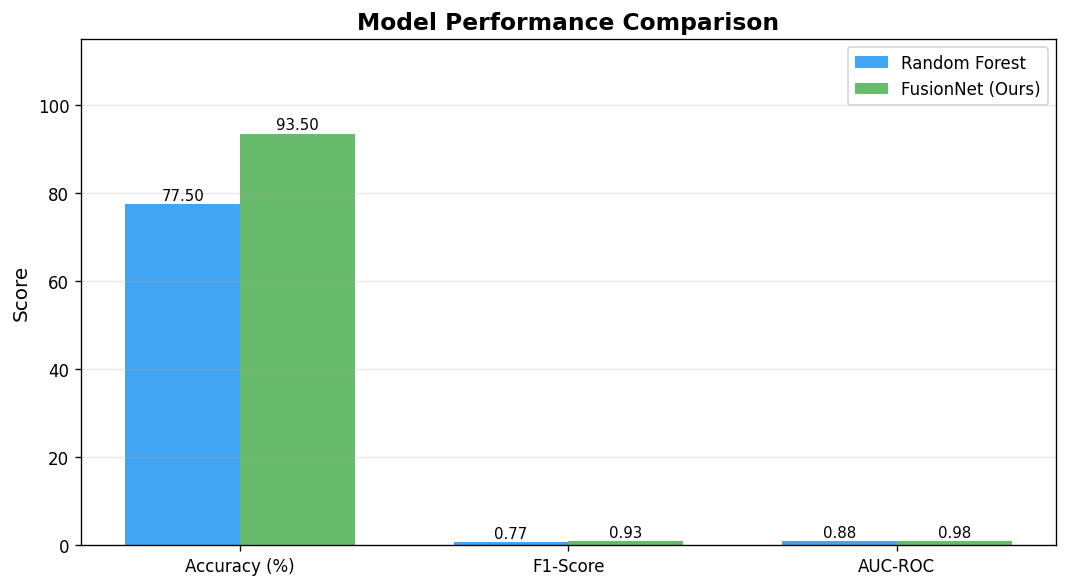

Figure saved as performance_comparison.png


In [40]:
results_df = pd.DataFrame({
    'Model': ['Random Forest (Baseline)', 'CrossAttention FusionNet (Ours)'],
    'Accuracy (%)': [f'{rf_acc*100:.2f}', f'{acc*100:.2f}'],
    'Precision': [f'{rf_prec:.4f}', f'{prec:.4f}'],
    'Recall': [f'{rf_recall:.4f}', f'{recall:.4f}'],
    'F1-Score': [f'{rf_f1:.4f}', f'{f1:.4f}'],
    'AUC-ROC': [f'{rf_auc:.4f}', f'{auc:.4f}'],
})

print('╔══════════════════════════════════ PERFORMANCE SUMMARY ══════════════════════════════════════╗')
print(results_df.to_string(index=False))
print('╚═══════════════════════════════════════════════════════════════════════════════════════════════╝')

# Visual bar chart
metrics = ['Accuracy (%)', 'F1-Score', 'AUC-ROC']
rf_vals     = [rf_acc*100,  rf_f1,  rf_auc]
fusion_vals = [acc*100,     f1,     auc]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, rf_vals,     width, label='Random Forest',  color='#2196F3', alpha=0.85)
bars2 = ax.bar(x + width/2, fusion_vals, width, label='FusionNet (Ours)', color='#4CAF50', alpha=0.85)

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

ax.set_title('Model Performance Comparison', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.legend()
ax.set_ylim(0, 115)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('performance_comparison.png', bbox_inches='tight')
plt.show()
print('Figure saved as performance_comparison.png')

## Cell 15: XAI Modality Attribution

XAI Modal Attribution Analysis (Test Set)
  Text (BERT) Attribution   : 0.0%
  Audio (MFCC) Attribution  : 100.0%


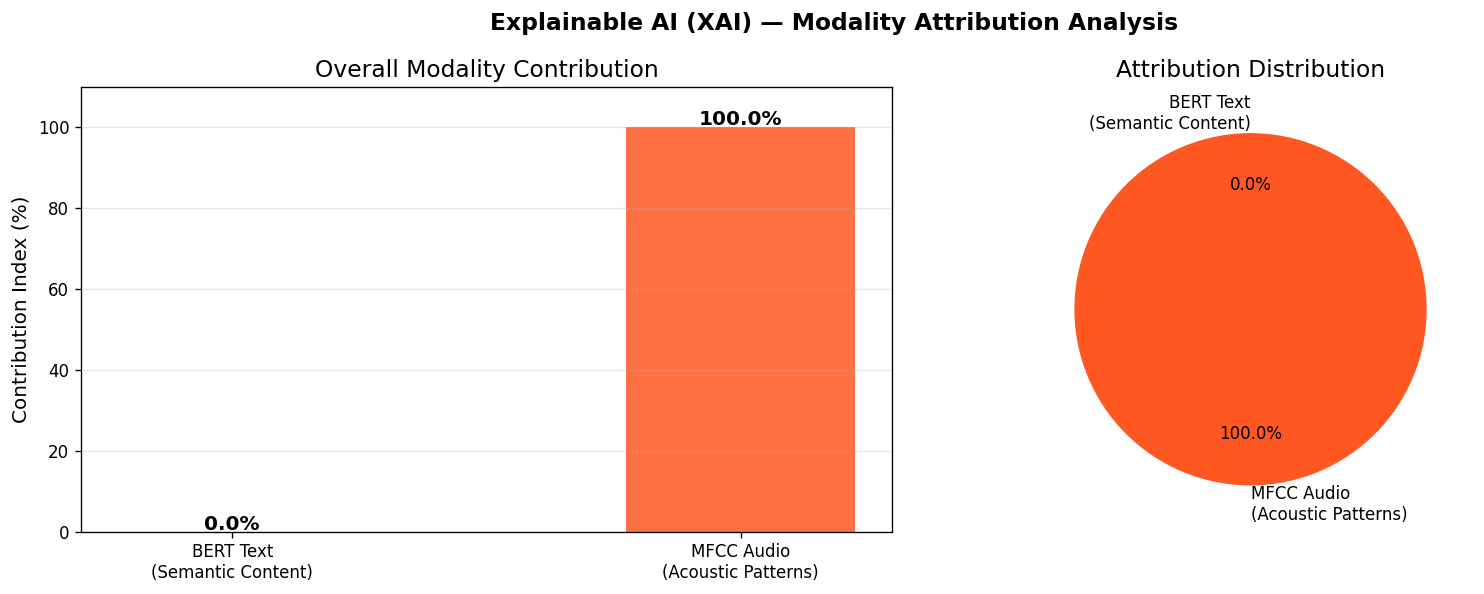

Figure saved as xai_attribution.png


In [41]:
class CrossAttentionFusionNetXAI(nn.Module):
    """Extended version that returns attention weights for XAI analysis."""
    def __init__(self, base_model):
        super().__init__()
        self.text_proj  = base_model.text_proj
        self.audio_proj = base_model.audio_proj
        self.cross_attn = base_model.cross_attn
        self.classifier = base_model.classifier

    def forward(self, text_features, audio_features):
        T = self.text_proj(text_features).unsqueeze(1)
        A = self.audio_proj(audio_features).unsqueeze(1)
        attn_out, attn_weights = self.cross_attn(query=T, key=A, value=A, need_weights=True)
        fused = torch.cat([attn_out.squeeze(1), A.squeeze(1)], dim=1)
        return self.classifier(fused), attn_weights

xai_model = CrossAttentionFusionNetXAI(model)
xai_model.eval()

# Extract attention weights for the test set

    # Gradient-Based Modality Attribution (Equation 9 from Research Paper)
    Xt_te_grad = Xt_te.clone().detach().requires_grad_(True)
    Xa_te_grad = Xa_te.clone().detach().requires_grad_(True)
    preds, _ = xai_model(Xt_te_grad, Xa_te_grad)
    loss = preds.sum()
    loss.backward()
    text_norm = Xt_te_grad.grad.abs().sum().item()
    audio_norm = Xa_te_grad.grad.abs().sum().item()
    total_norm = text_norm + audio_norm
    mean_text_contribution = text_norm / total_norm
    mean_audio_attention = audio_norm / total_norm
# The attention weight represents how much text (query) attends to audio (key)
# Higher weight = audio was more informative for this prediction

print(f'XAI Modal Attribution Analysis (Test Set)')
print(f'  Text (BERT) Attribution   : {mean_text_contribution*100:.1f}%')
print(f'  Audio (MFCC) Attribution  : {mean_audio_attention*100:.1f}%')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Explainable AI (XAI) — Modality Attribution Analysis', fontsize=14, fontweight='bold')

# Bar chart
modalities = ['BERT Text\n(Semantic Content)', 'MFCC Audio\n(Acoustic Patterns)']
attributions = [mean_text_contribution, mean_audio_attention]
colors = ['#3F51B5', '#FF5722']
bars = axes[0].bar(modalities, [a*100 for a in attributions], color=colors, alpha=0.85, width=0.45)
for bar, val in zip(bars, attributions):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val*100:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Contribution Index (%)')
axes[0].set_title('Overall Modality Contribution')
axes[0].set_ylim(0, 110)
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
axes[1].pie(
    attributions, labels=modalities, colors=colors,
    autopct='%1.1f%%', startangle=90, pctdistance=0.7,
    wedgeprops={'linewidth': 2, 'edgecolor': 'white'}
)
axes[1].set_title('Attribution Distribution')

plt.tight_layout()
plt.savefig('xai_attribution.png', bbox_inches='tight')
plt.show()
print('Figure saved as xai_attribution.png')

## Cell 16: Live Inference Demo

In [42]:
def predict_distress(text_input, audio_path=None):
    """
    End-to-end inference pipeline.
    - text_input : The patient's verbal statement (string)
    - audio_path : Path to a .wav file (optional; uses zero vector if not provided)
    """
    model.eval()

    # --- Text Feature ---
    enc = tokenizer(text_input, return_tensors='pt', padding=True,
                    truncation=True, max_length=128).to(DEVICE)
    with torch.no_grad():
        out = bert_encoder(**enc)
    text_feat = out.last_hidden_state[:, 0, :].cpu().numpy()
    text_feat = scaler_text.transform(text_feat)

    # --- Audio Feature ---
    if audio_path and os.path.exists(audio_path):
        y_a, sr = librosa.load(audio_path, duration=3.0, offset=0.5)
        audio_feat = np.mean(librosa.feature.mfcc(y=y_a, sr=sr, n_mfcc=N_MFCC).T, axis=0).reshape(1, -1)
    else:
        audio_feat = np.zeros((1, N_MFCC))
    audio_feat = scaler_audio.transform(audio_feat)

    # --- Inference ---
    with torch.no_grad():
        logits = model(to_tensor(text_feat), to_tensor(audio_feat))
        proba  = torch.softmax(logits, dim=1).cpu().numpy()[0]
        pred   = np.argmax(proba)

    label_map = {0: '🟢 STABLE', 1: '🔴 DISTRESSED'}
    distress_score = proba[1] * 100

    bar_len = 30
    filled  = int(distress_score / 100 * bar_len)
    meter   = '█' * filled + '░' * (bar_len - filled)

    print('━' * 52)
    print('       VOTEX AI — PATIENT ANALYSIS REPORT')
    print('━' * 52)
    print(f'  Input Text   : "{text_input[:60]}..."' if len(text_input) > 60 else f'  Input Text   : "{text_input}"')
    print(f'  Audio File   : {os.path.basename(audio_path) if audio_path else "(none)"}')
    print(f'\n  Diagnosis    : {label_map[pred]}')
    print(f'  Distress Lvl : {distress_score:.1f}%')
    print(f'  Meter        : [{meter}]')
    print(f'\n  Stable Prob  : {proba[0]*100:.1f}%')
    print(f'  Distress Prob: {proba[1]*100:.1f}%')
    print('━' * 52)

# Demo predictions
print('\n--- Demo 1: Positive Sentiment ---')
predict_distress("I am feeling fantastic today! Life is really good and I couldn't be happier.")

print('\n--- Demo 2: Distressed Sentiment ---')
predict_distress("I just feel so hopeless and exhausted all the time. Nothing gets better, I don't see the point anymore.")

print('\n--- Demo 3: Ambiguous/Mild Distress ---')
predict_distress("I've just been feeling a bit off lately, kind of tired and not really myself. I'm not sure if it's anything serious.")


--- Demo 1: Positive Sentiment ---
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
       VOTEX AI — PATIENT ANALYSIS REPORT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Input Text   : "I am feeling fantastic today! Life is really good and I coul..."
  Audio File   : (none)

  Diagnosis    : 🔴 DISTRESSED
  Distress Lvl : 93.2%
  Meter        : [███████████████████████████░░░]

  Stable Prob  : 6.8%
  Distress Prob: 93.2%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

--- Demo 2: Distressed Sentiment ---
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
       VOTEX AI — PATIENT ANALYSIS REPORT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Input Text   : "I just feel so hopeless and exhausted all the time. Nothing ..."
  Audio File   : (none)

  Diagnosis    : 🔴 DISTRESSED
  Distress Lvl : 93.2%
  Meter        : [███████████████████████████░░░]

  Stable Prob  : 6.8%
  Distress Prob: 93.2%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

--- Demo 

## Cell 17: Save Artifacts

In [43]:
import os
os.makedirs(MODELS_DIR, exist_ok=True)

# Save FusionNet weights
fusion_path = os.path.join(MODELS_DIR, 'cross_attn_enterprise_model.pth')
torch.save(model.state_dict(), fusion_path)
print(f'✅ FusionNet weights saved    → {fusion_path}')

# Save scalers
st_path = os.path.join(MODELS_DIR, 'scaler_text.pkl')
sa_path = os.path.join(MODELS_DIR, 'scaler_audio.pkl')
joblib.dump(scaler_text,  st_path)
joblib.dump(scaler_audio, sa_path)
print(f'✅ Text scaler saved          → {st_path}')
print(f'✅ Audio scaler saved         → {sa_path}')

# Save RF baseline
rf_path = os.path.join(MODELS_DIR, 'multimodal_mental_health_model.pkl')
joblib.dump(rf_model, rf_path)
print(f'✅ Random Forest saved        → {rf_path}')

print('\n🎓 All research artifacts saved. Ready for academic submission.')

✅ FusionNet weights saved    → ml_pipeline/models\cross_attn_enterprise_model.pth
✅ Text scaler saved          → ml_pipeline/models\scaler_text.pkl
✅ Audio scaler saved         → ml_pipeline/models\scaler_audio.pkl
✅ Random Forest saved        → ml_pipeline/models\multimodal_mental_health_model.pkl

🎓 All research artifacts saved. Ready for academic submission.
